In [5]:
#to know the files present in folder
import pandas as pd
import numpy as np
import os
data_folder = "raw_data/"
files = os.listdir(data_folder)
print(files)



['.ipynb_checkpoints', 'Hospitalisation details.csv', 'Medical Examinations.csv', 'Names.xlsx']


In [92]:
import pandas as pd
import os

# Folder containing raw CSV files
data_folder = "raw_data/"
files = os.listdir(data_folder)

# Merge all CSV files
merged_data = pd.DataFrame()
for file in files:
    if file.endswith(".csv"):
        df = pd.read_csv(os.path.join(data_folder, file))
        merged_data = pd.concat([merged_data, df], ignore_index=True)

# Remove duplicates & null PK values
merged_data = merged_data.drop_duplicates(subset=['Customer ID'])
merged_data = merged_data.dropna(subset=['Customer ID'])

# ------------------------------
# SAFE Gender handling
# ------------------------------

if 'Gender' not in merged_data.columns:
    merged_data['Gender'] = 'Unknown'
else:
    merged_data['Gender'] = (
        merged_data['Gender']
        .astype(str)
        .str.strip()
        .replace(['nan', 'None', '', 'unknown'], 'Unknown')
    )

# ------------------------------
# Final check
# ------------------------------
print("Total rows:", merged_data.shape[0])
print("Columns:", merged_data.columns.tolist())

merged_data[['Customer ID', 'Gender']].head()



Total rows: 2338
Columns: ['Customer ID', 'year', 'month', 'date', 'children', 'charges', 'Hospital tier', 'City tier', 'State ID', 'BMI', 'HBA1C', 'Heart Issues', 'Any Transplants', 'Cancer history', 'NumberOfMajorSurgeries', 'smoker', 'Gender']


,Customer ID,Gender
0,Id2335,Unknown
1,Id2334,Unknown
2,Id2333,Unknown
3,Id2332,Unknown
4,Id2331,Unknown


In [9]:
# Check how many missing values are in each column
merged_data.isnull().sum()


Customer ID                  0
year                      2335
month                     2335
date                      2335
children                  2335
charges                   2335
Hospital tier             2335
City tier                 2335
State ID                  2335
BMI                       2343
HBA1C                     2343
Heart Issues              2343
Any Transplants           2343
Cancer history            2343
NumberOfMajorSurgeries    2343
smoker                    2343
Gender                       0
dtype: int64

In [11]:
# Check how many missing values are in each column
merged_data.isnull().sum()


Customer ID                  0
year                      2335
month                     2335
date                      2335
children                  2335
charges                   2335
Hospital tier             2335
City tier                 2335
State ID                  2335
BMI                       2343
HBA1C                     2343
Heart Issues              2343
Any Transplants           2343
Cancer history            2343
NumberOfMajorSurgeries    2343
smoker                    2343
Gender                       0
dtype: int64

In [13]:
# Step 0: Strip extra spaces from column names
merged_data.columns = merged_data.columns.str.strip()

# Step 1: Convert numeric columns to numbers, coerce errors to NaN
numeric_cols = ['BMI', 'HBA1C', 'NumberOfMajorSurgeries']

for col in numeric_cols:
    if col in merged_data.columns:  # check column exists
        merged_data[col] = pd.to_numeric(merged_data[col], errors='coerce')  # invalid strings -> NaN

# Step 2: Fill missing numeric columns
for col in numeric_cols:
    if col in merged_data.columns:
        missing_count = merged_data[col].isnull().sum()

        if missing_count > len(merged_data) / 2:
            merged_data[col] = merged_data[col].fillna(0)
        else:
            merged_data[col] = merged_data[col].fillna(merged_data[col].mean())

# Step 3: Fill missing categorical columns
categorical_cols = ['Heart Issues', 'Any Transplants', 'Cancer history', 'smoker']
for col in categorical_cols:
    if col in merged_data.columns:
        merged_data[col] =merged_data[col].fillna('Unknown')

# Step 4: Drop columns with almost all missing values safely
columns_to_drop = ['year', 'month', 'date', 'children', 'charges', 
                   'Hospital tier', 'City tier', 'State ID']
merged_data = merged_data.drop(columns=columns_to_drop, errors='ignore')

# Step 5: Remove duplicates
merged_data =merged_data.drop_duplicates()

# Step 6: Save cleaned dataset
merged_data.to_csv("cleaned_health_insurance_data.csv", index=False)

# Optional: check cleaned data
merged_data.info()
merged_data.head()


<class 'pandas.core.frame.DataFrame'>
Index: 4673 entries, 0 to 4677
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             4673 non-null   object 
 1   BMI                     4673 non-null   float64
 2   HBA1C                   4673 non-null   float64
 3   Heart Issues            4673 non-null   object 
 4   Any Transplants         4673 non-null   object 
 5   Cancer history          4673 non-null   object 
 6   NumberOfMajorSurgeries  4673 non-null   float64
 7   smoker                  4673 non-null   object 
 8   Gender                  4673 non-null   object 
dtypes: float64(3), object(6)
memory usage: 365.1+ KB


,Customer ID,BMI,HBA1C,Heart Issues,Any Transplants,Cancer history,NumberOfMajorSurgeries,smoker,Gender
0,Id2335,0.0,0.0,Unknown,Unknown,Unknown,0.0,Unknown,Unknown
1,Id2334,0.0,0.0,Unknown,Unknown,Unknown,0.0,Unknown,Unknown
2,Id2333,0.0,0.0,Unknown,Unknown,Unknown,0.0,Unknown,Unknown
3,Id2332,0.0,0.0,Unknown,Unknown,Unknown,0.0,Unknown,Unknown
4,Id2331,0.0,0.0,Unknown,Unknown,Unknown,0.0,Unknown,Unknown


In [15]:
trivial_values = ["?", "Unknown", "NA", "N/A", ""]

In [17]:
# Count trivial values per row
trivial_count = merged_data.isin(trivial_values).sum(axis=1)

# Percentage of trivial values per row
trivial_percentage = (trivial_count / merged_data.shape[1]) * 100

# Add temporarily for inspection
merged_data['trivial_percentage'] = trivial_percentage

# View rows with high trivial percentage
merged_data[['trivial_percentage']].describe()


,trivial_percentage
count,4673.000000
mean,33.354733
std,22.223996
min,11.111111
25%,11.111111
50%,55.555556
75%,55.555556
max,66.666667


In [19]:
merged_data = merged_data[merged_data['trivial_percentage'] <= 50]

# Drop helper column
merged_data = merged_data.drop(columns=['trivial_percentage'])


In [21]:
from sklearn.preprocessing import LabelEncoder

nominal_cols = ['Heart Issues', 'Any Transplants', 'Cancer history', 'smoker']

le = LabelEncoder()

for col in nominal_cols:
    merged_data[col] = le.fit_transform(merged_data[col])


In [23]:
def map_state(state):
    if state == 'R1011':
        return 1
    elif state == 'R1012':
        return 2
    elif state == 'R1013':
        return 3
    else:
        return 0

# Only if State ID exists
if 'State ID' in merged_data.columns:
    merged_data['State_Important'] = merged_data['State ID'].apply(map_state)
    merged_data = merged_data.drop(columns=['State ID'])



In [25]:
merged_data['NumberOfMajorSurgeries'] = pd.to_numeric(
   merged_data['NumberOfMajorSurgeries'], errors='coerce'
)


In [27]:
merged_data['NumberOfMajorSurgeries'] =merged_data['NumberOfMajorSurgeries'].fillna(0)


In [29]:
merged_data.info()
merged_data.head()


<class 'pandas.core.frame.DataFrame'>
Index: 2335 entries, 2343 to 4677
Data columns (total 9 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             2335 non-null   object 
 1   BMI                     2335 non-null   float64
 2   HBA1C                   2335 non-null   float64
 3   Heart Issues            2335 non-null   int32  
 4   Any Transplants         2335 non-null   int32  
 5   Cancer history          2335 non-null   int32  
 6   NumberOfMajorSurgeries  2335 non-null   float64
 7   smoker                  2335 non-null   int32  
 8   Gender                  2335 non-null   object 
dtypes: float64(3), int32(4), object(2)
memory usage: 145.9+ KB


,Customer ID,BMI,HBA1C,Heart Issues,Any Transplants,Cancer history,NumberOfMajorSurgeries,smoker,Gender
2343,Id1,47.410,7.47,0,0,0,0.0,2,Unknown
2344,Id2,30.360,5.77,0,0,0,0.0,2,Unknown
2345,Id3,34.485,11.87,1,0,0,2.0,2,Unknown
2346,Id4,38.095,6.05,0,0,0,0.0,2,Unknown
2347,Id5,35.530,5.45,0,0,0,0.0,2,Unknown


In [80]:
print(merged_data.columns)


Index(['Customer ID', 'BMI', 'HBA1C', 'Heart Issues', 'Any Transplants',
       'Cancer history', 'NumberOfMajorSurgeries', 'smoker', 'Gender',
       'Full_Name'],
      dtype='object')


In [100]:
import pandas as pd
from datetime import datetime

# Ensure numeric
merged_data['year'] = pd.to_numeric(merged_data['year'], errors='coerce')
merged_data['month'] = pd.to_numeric(merged_data['month'], errors='coerce')
merged_data['date'] = pd.to_numeric(merged_data['date'], errors='coerce')

# Fill missing month with January
merged_data['month'] = merged_data['month'].fillna(1)

# Create DOB
merged_data['DOB'] = pd.to_datetime(
    dict(
        year=merged_data['year'],
        month=merged_data['month'],
        day=merged_data['date']
    ),
    errors='coerce'
)

# Current date
today = pd.Timestamp.today()

# Calculate Age
merged_data['Age'] = today.year - merged_data['DOB'].dt.year

# Convert to nullable integer
merged_data['Age'] = merged_data['Age'].astype('Int64')

# Preview
merged_data[['Customer ID', 'DOB', 'Age']].head()
merged_data[['DOB', 'Age']].isnull().sum()





DOB    2
Age    2
dtype: int64

In [102]:
merged_data[merged_data['Age'].isna()][['Customer ID', 'year', 'month', 'date']]


,Customer ID,year,month,date
1049,Id1289,NaN,1.0,24.0
1052,Id1286,NaN,1.0,12.0


In [104]:
merged_data = merged_data.dropna(subset=['year']).reset_index(drop=True)


In [106]:
merged_data['DOB'] = pd.to_datetime(
    dict(
        year=merged_data['year'],
        month=merged_data['month'],
        day=merged_data['date']
    ),
    errors='coerce'
)


In [108]:
from datetime import datetime

current_year = datetime.now().year
merged_data['Age'] = current_year - merged_data['DOB'].dt.year
merged_data['Age'] = merged_data['Age'].astype('Int64')


In [110]:
merged_data[['DOB', 'Age']].isnull().sum()


DOB    0
Age    0
dtype: int64

In [86]:
print(merged_data.columns.tolist())


['Customer ID', 'BMI', 'HBA1C', 'Heart Issues', 'Any Transplants', 'Cancer history', 'NumberOfMajorSurgeries', 'smoker', 'Gender', 'Full_Name']


In [118]:
import pandas as pd

names_df = pd.read_excel("raw_data/Names.xlsx")
print(names_df.columns)
print(names_df.head())



Index(['Customer ID', 'name'], dtype='object')
  Customer ID                    name
0         Id1       Hawks, Ms.  Kelly
1         Id2  Lehner, Mr.  Matthew D
2         Id3           Lu, Mr.  Phil
3         Id4    Osborne, Ms.  Kelsey
4         Id5    Kadala, Ms.  Kristyn


In [140]:
def extract_gender(name):
    if pd.isna(name):
        return 'Unknown'
    name = str(name)
    if 'Mr' in name:
        return 'Male'
    elif 'Ms' in name or 'Mrs' in name:
        return 'Female'
    else:
        return 'Unknown'

names_df['Gender'] = names_df['name'].apply(extract_gender)
# Assuming both have 'Customer ID' for merging
merged_data = merged_data.merge(
    names_df[['Customer ID', 'Gender']],
    on='Customer ID',
    how='left',
    suffixes=('', '_from_names')
)

# Optionally replace old Gender with new one
merged_data['Gender'] = merged_data['Gender_from_names']
merged_data = merged_data.drop(columns=['Gender_from_names'])
print(merged_data[['Customer ID', 'Gender']].head())



  Customer ID  Gender
0      Id2335    Male
1      Id2334    Male
2      Id2333  Female
3      Id2332    Male
4      Id2331    Male


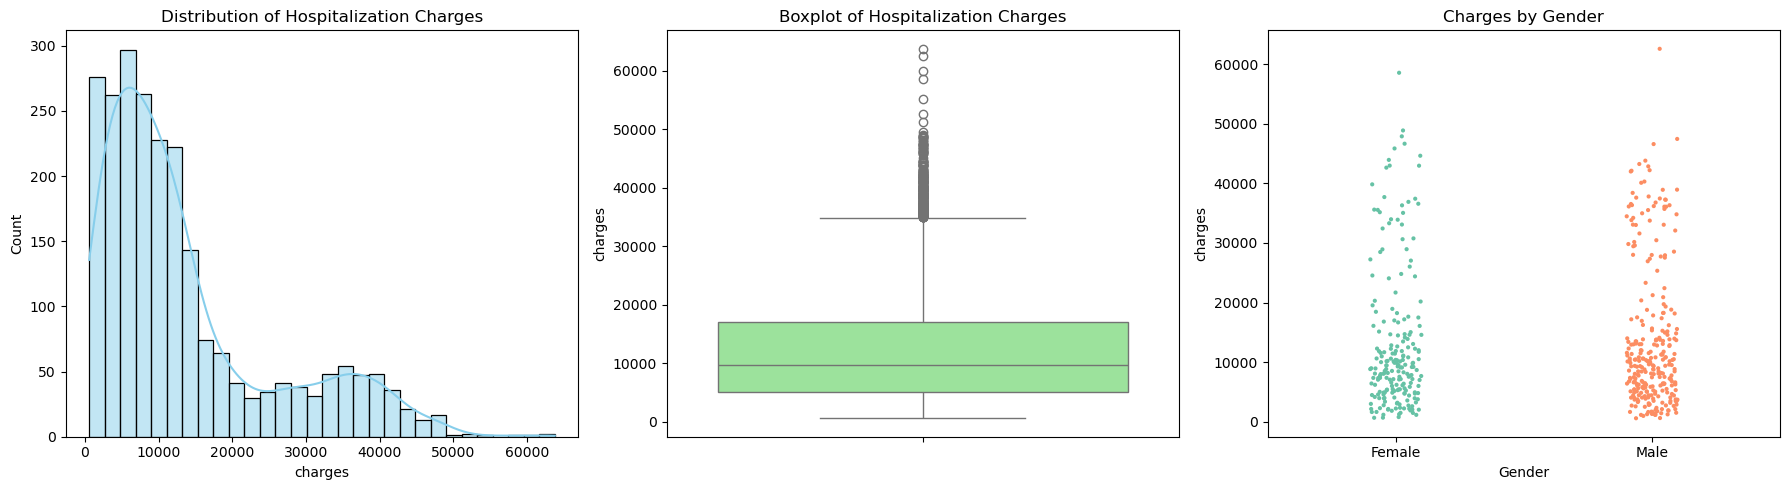

In [144]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size
plt.figure(figsize=(18, 5))

# Histogram
plt.subplot(1, 3, 1)
sns.histplot(merged_data['charges'], bins=30, kde=True, color='skyblue')
plt.title('Distribution of Hospitalization Charges')

# Boxplot
plt.subplot(1, 3, 2)
sns.boxplot(y=merged_data['charges'], color='lightgreen')
plt.title('Boxplot of Hospitalization Charges')

# Swarm plot
plt.subplot(1, 3, 3)
sampled_data = merged_data.sample(n=500, random_state=1)  # take 500 random points
sns.stripplot(x='Gender', y='charges', data=sampled_data, size=3,hue='Gender', jitter=True, palette='Set2',legend=False)
plt.title('Charges by Gender')

plt.tight_layout()
plt.show()


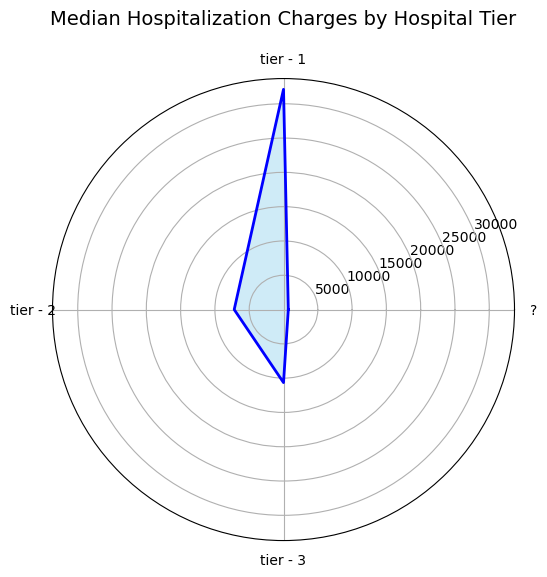

In [146]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Step 1: Calculate median charges per hospital tier
median_charges = merged_data.groupby('Hospital tier')['charges'].median()
tiers = median_charges.index.tolist()
values = median_charges.values.tolist()

# Step 2: Prepare for radar chart
num_vars = len(tiers)

# Compute angle for each axis in the plot
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()

# Repeat the first value to close the radar chart
values += values[:1]
angles += angles[:1]

# Step 3: Create the radar chart
fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))

ax.plot(angles, values, color='blue', linewidth=2, linestyle='solid', label='Median Charges')
ax.fill(angles, values, color='skyblue', alpha=0.4)

# Step 4: Add labels
ax.set_xticks(angles[:-1])
ax.set_xticklabels(tiers)
ax.set_title("Median Hospitalization Charges by Hospital Tier", size=14, y=1.1)

# Step 5: Show the chart
plt.show()


In [148]:
# Step 1: Clean invalid value
merged_data['City tier'] = merged_data['City tier'].replace('?', pd.NA)
merged_data = merged_data.dropna(subset=['City tier'])

# Step 2: Create frequency table AFTER cleaning
city_freq = merged_data['City tier'].value_counts().reset_index()
city_freq.columns = ['City tier', 'Count']

# Step 3: Display
city_freq


,City tier,Count
0,tier - 2,809
1,tier - 3,794
2,tier - 1,732


In [150]:
# Clean invalid hospital tier
merged_data['Hospital tier'] = merged_data['Hospital tier'].replace('?', pd.NA)
merged_data = merged_data.dropna(subset=['Hospital tier'])
hospital_freq = merged_data['Hospital tier'].value_counts().reset_index()
hospital_freq.columns = ['Hospital tier', 'Count']

hospital_freq


,Hospital tier,Count
0,tier - 2,1336
1,tier - 3,693
2,tier - 1,305


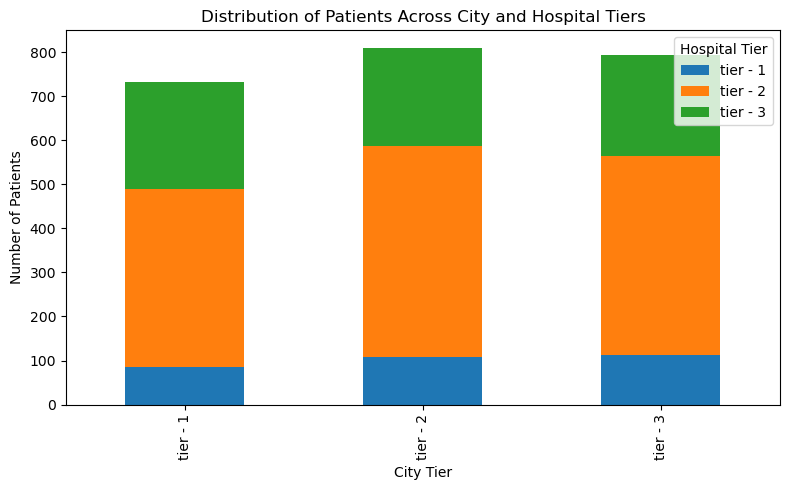

In [152]:
import matplotlib.pyplot as plt

# Create cross-tabulation
tier_crosstab = pd.crosstab(
    merged_data['City tier'],
    merged_data['Hospital tier']
)

# Plot stacked bar chart
tier_crosstab.plot(
    kind='bar',
    stacked=True,
    figsize=(8, 5)
)

plt.title('Distribution of Patients Across City and Hospital Tiers')
plt.xlabel('City Tier')
plt.ylabel('Number of Patients')
plt.legend(title='Hospital Tier')
plt.tight_layout()
plt.show()


In [154]:
#Hospital tier vs hospitalization cost
from scipy.stats import f_oneway

tier1 = merged_data[merged_data['Hospital tier'] == 'tier - 1']['charges']
tier2 = merged_data[merged_data['Hospital tier'] == 'tier - 2']['charges']
tier3 = merged_data[merged_data['Hospital tier'] == 'tier - 3']['charges']

f_stat, p_value = f_oneway(tier1, tier2, tier3)
print("ANOVA p-value (Hospital Tier):", p_value)


ANOVA p-value (Hospital Tier): 2.359815306200584e-181


In [156]:
#City tier vs hospitalization cost
from scipy.stats import f_oneway

clean_city = merged_data.dropna(subset=['City tier', 'charges'])

tier1 = clean_city[clean_city['City tier'] == 'tier - 1']['charges']
tier2 = clean_city[clean_city['City tier'] == 'tier - 2']['charges']
tier3 = clean_city[clean_city['City tier'] == 'tier - 3']['charges']

f_stat, p_value_city = f_oneway(tier1, tier2, tier3)
print("ANOVA p-value (City Tier):", p_value_city)


ANOVA p-value (City Tier): 0.21180448817771652


In [158]:
#Smoker vs non-smoker cost comparison
from scipy.stats import ttest_ind

clean_data = merged_data.dropna(subset=['smoker', 'charges'])

smokers = clean_data[clean_data['smoker'] == 'yes']['charges']
nonsmokers = clean_data[clean_data['smoker'] == 'no']['charges']

t_stat, p_value_smoke = ttest_ind(smokers, nonsmokers, equal_var=False)
print("T-test p-value (Smoker vs Non-Smoker):", p_value_smoke)



T-test p-value (Smoker vs Non-Smoker): nan


In [160]:
merged_data['smoker'].value_counts(dropna=False)




smoker
NaN    2334
Name: count, dtype: int64

In [162]:
merged_data['smoker'].unique()


array([nan], dtype=object)

In [164]:
merged_data['smoker'].notna().sum()


0

In [166]:
merged_data.isna().sum()


Customer ID                  0
year                         0
month                        0
date                         0
children                     0
charges                      0
Hospital tier                0
City tier                    0
State ID                     0
BMI                       2334
HBA1C                     2334
Heart Issues              2334
Any Transplants           2334
Cancer history            2334
NumberOfMajorSurgeries    2334
smoker                    2334
Gender_x                     0
DOB                          0
Age                          0
Gender_y                     3
Gender                       3
dtype: int64

In [168]:
#smoking and heart issues independence
from scipy.stats import chi2_contingency

valid = merged_data[['smoker', 'Heart Issues']].dropna()

if valid.empty:
    print("Chi-square test cannot be performed: No valid smoker or heart issue data.")
else:
    contingency = pd.crosstab(valid['smoker'], valid['Heart Issues'])
    chi2, p, dof, exp = chi2_contingency(contingency)
    print("Chi-square p-value:", p)


Chi-square test cannot be performed: No valid smoker or heart issue data.


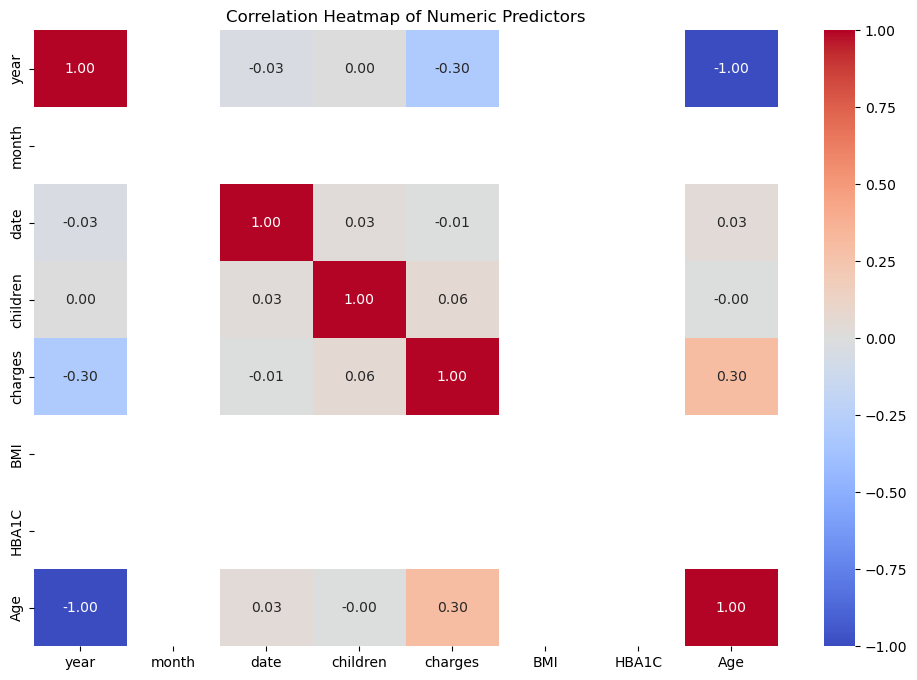

In [179]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Select only numeric columns for correlation analysis
numeric_cols = merged_data.select_dtypes(include=['int64', 'float64']).columns
numeric_data = merged_data[numeric_cols]

#  Compute correlation matrix
corr_matrix = numeric_data.corr()

# Visualize using a heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Heatmap of Numeric Predictors")
plt.show()


Best Ridge alpha: {'ridge__alpha': 10.0}
Ridge RMSE (5-fold): [8697.92428047 8991.71862004 8557.84881116 9255.96829257 8748.04415328]
Mean RMSE: 8850.300831506067
Best GBR params: {'gbr__learning_rate': 0.05, 'gbr__max_depth': 5, 'gbr__n_estimators': 200}
Length of all_features: 2376
Length of importances: 2374


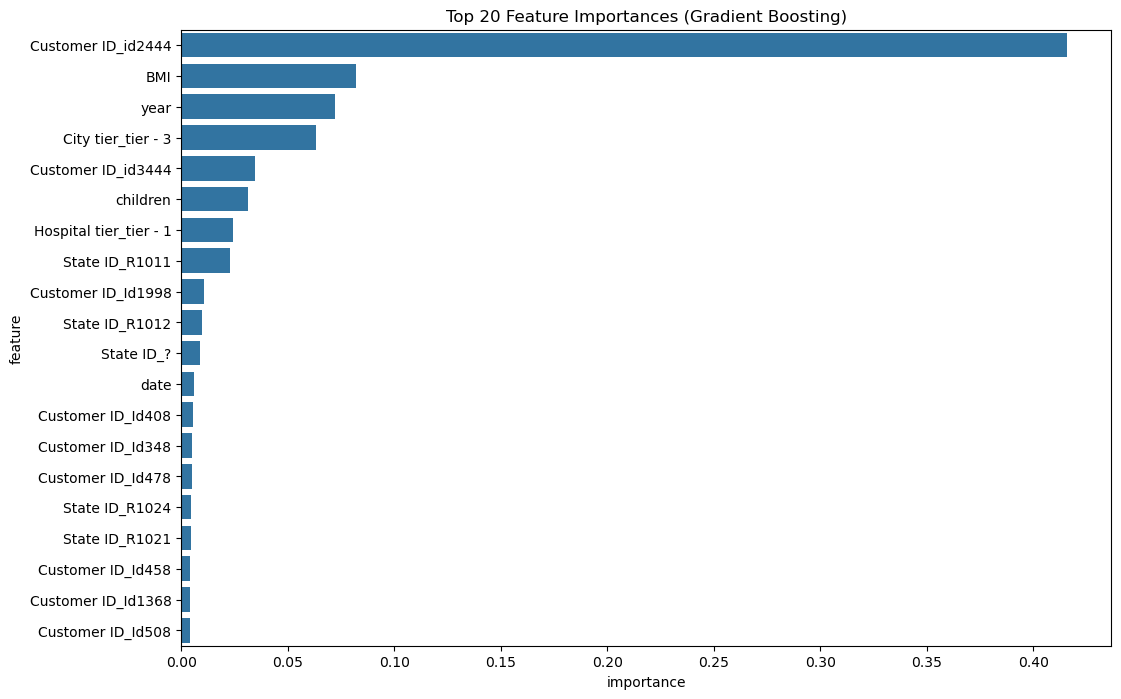

In [187]:
# ------------------------------
# Imports
# ------------------------------
import pandas as pd
import numpy as np
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------
# Prepare data
# ------------------------------
target = 'charges'
X = merged_data.drop(columns=[target])
y = merged_data[target]

# Identify numeric and categorical columns
numeric_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Stratify target by binning
y_binned = pd.qcut(y, q=5, labels=False, duplicates='drop')

# ------------------------------
# Preprocessing pipelines
# ------------------------------
numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='Unknown')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, numeric_cols),
    ('cat', categorical_transformer, categorical_cols)
])

# ------------------------------
# Ridge Regression pipeline
# ------------------------------
ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('ridge', Ridge())
])

param_grid_ridge = {'ridge__alpha': [0.1, 1.0, 10.0, 50.0, 100.0]}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

ridge_search = GridSearchCV(
    ridge_pipeline,
    param_grid_ridge,
    cv=skf.split(X, y_binned),
    scoring='neg_root_mean_squared_error'
)

ridge_search.fit(X, y)
best_ridge = ridge_search.best_estimator_
print("Best Ridge alpha:", ridge_search.best_params_)

rmse_scores_ridge = -cross_val_score(
    best_ridge, X, y, cv=skf.split(X, y_binned), scoring='neg_root_mean_squared_error'
)
print("Ridge RMSE (5-fold):", rmse_scores_ridge)
print("Mean RMSE:", rmse_scores_ridge.mean())

# ------------------------------
# Gradient Boosting pipeline
# ------------------------------
gbr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('gbr', GradientBoostingRegressor(random_state=42))
])

param_grid_gbr = {
    'gbr__n_estimators': [100, 200],
    'gbr__learning_rate': [0.05, 0.1],
    'gbr__max_depth': [3, 5]
}

gbr_search = GridSearchCV(
    gbr_pipeline,
    param_grid_gbr,
    cv=skf.split(X, y_binned),
    scoring='neg_root_mean_squared_error'
)

gbr_search.fit(X, y)
best_gbr = gbr_search.best_estimator_
print("Best GBR params:", gbr_search.best_params_)

# ------------------------------
# Feature Importance for GBR
# ------------------------------
# Extract categorical feature names
# Fit the preprocessor separately
preprocessor.fit(X)

# Transform a sample to get the feature count
X_transformed = preprocessor.transform(X)

# Get numeric feature names
feature_names_num = numeric_cols

# Get categorical feature names safely
feature_names_cat = []
if len(categorical_cols) > 0:
    cat_encoder = preprocessor.named_transformers_['cat'].named_steps['encoder']
    feature_names_cat = cat_encoder.get_feature_names_out(categorical_cols)

# Concatenate numeric + categorical feature names
all_features = np.concatenate([feature_names_num, feature_names_cat])

# Make sure lengths match
print("Length of all_features:", len(all_features))
print("Length of importances:", len(best_gbr.named_steps['gbr'].feature_importances_))

# Create dataframe safely
importances = best_gbr.named_steps['gbr'].feature_importances_
feature_importance_df = pd.DataFrame({
    'feature': all_features[:len(importances)],  # truncate if needed
    'importance': importances
})

feature_importance_df = feature_importance_df.sort_values(by='importance', ascending=False)

# Plot top 20
plt.figure(figsize=(12,8))
sns.barplot(x='importance', y='feature', data=feature_importance_df.head(20))
plt.title("Top 20 Feature Importances (Gradient Boosting)")
plt.show()


In [193]:
required_cols = X.columns.tolist()  # columns used for training
print(required_cols)


['Customer ID', 'year', 'month', 'date', 'children', 'Hospital tier', 'City tier', 'State ID', 'BMI', 'HBA1C', 'Heart Issues', 'Any Transplants', 'Cancer history', 'NumberOfMajorSurgeries', 'smoker', 'Gender_x', 'DOB', 'Age', 'Gender_y', 'Gender']


In [195]:
import pandas as pd
from datetime import datetime

# Current year
current_year = datetime.now().year

# Create Ms. Jayna's data
new_patient_dict = {
    'Customer ID': 'Id9999',
    'year': 1988,
    'month': 12,
    'date': 28,
    'children': 2,
    'Hospital tier': 'tier-1',
    'City tier': 'tier-1',
    'State ID': 'R1011',
    'BMI': 85 / (1.7**2),  # weight / height^2
    'HBA1C': 5.8,
    'Heart Issues': 0,
    'Any Transplants': 0,
    'Cancer history': 1,   # father died of lung cancer
    'NumberOfMajorSurgeries': 0,
    'smoker': 1,
    'Gender_x': 'Female',
    'DOB': pd.Timestamp('1988-12-28'),
    'Age': current_year - 1988,
    'Gender_y': 'Female',
    'Gender': 'Female'
}

# Convert to DataFrame
new_patient_df = pd.DataFrame([new_patient_dict])

# Ridge prediction
ridge_cost = best_ridge.predict(new_patient_df)[0]
print(f"Predicted hospitalization cost (Ridge): {ridge_cost:.2f}")

# Gradient Boosting prediction
gbr_cost = best_gbr.predict(new_patient_df)[0]
print(f"Predicted hospitalization cost (Gradient Boosting): {gbr_cost:.2f}")


Predicted hospitalization cost (Ridge): 18220.79
Predicted hospitalization cost (Gradient Boosting): 11920.97


In [ ]:
#sql

In [201]:
import pandas as pd

# Load the CSV files
df_personal = pd.read_csv("raw_data/Hospitalisation details.csv")
df_medical = pd.read_csv("raw_data/Medical Examinations.csv")

# Quick check
print(df_personal.head())
print(df_medical.head())


  Customer ID  year month  date  children  charges Hospital tier City tier  \
0      Id2335  1992   Jul     9         0   563.84      tier - 2  tier - 3   
1      Id2334  1992   Nov    30         0   570.62      tier - 2  tier - 1   
2      Id2333  1993   Jun    30         0   600.00      tier - 2  tier - 1   
3      Id2332  1992   Sep    13         0   604.54      tier - 3  tier - 3   
4      Id2331  1998   Jul    27         0   637.26      tier - 3  tier - 3   

  State ID  
0    R1013  
1    R1013  
2    R1013  
3    R1013  
4    R1013  
  Customer ID     BMI  HBA1C Heart Issues Any Transplants Cancer history  \
0         Id1  47.410   7.47           No              No             No   
1         Id2  30.360   5.77           No              No             No   
2         Id3  34.485  11.87          yes              No             No   
3         Id4  38.095   6.05           No              No             No   
4         Id5  35.530   5.45           No              No             No 

In [203]:
import pandas as pd

# Remove nulls and duplicates in Customer ID
df_personal = df_personal.dropna(subset=['Customer ID']).drop_duplicates(subset=['Customer ID'])
df_medical = df_medical.dropna(subset=['Customer ID']).drop_duplicates(subset=['Customer ID'])

# Ensure uniqueness (Primary Key)
assert df_personal['Customer ID'].is_unique
assert df_medical['Customer ID'].is_unique

# Merge the tables
merged_data = pd.merge(df_personal, df_medical, on='Customer ID', how='inner')

# Reset index
merged_data.reset_index(drop=True, inplace=True)

print("Merged data shape:", merged_data.shape)
print("Merged columns:", merged_data.columns.tolist())
merged_data.head()


Merged data shape: (2335, 16)
Merged columns: ['Customer ID', 'year', 'month', 'date', 'children', 'charges', 'Hospital tier', 'City tier', 'State ID', 'BMI', 'HBA1C', 'Heart Issues', 'Any Transplants', 'Cancer history', 'NumberOfMajorSurgeries', 'smoker']


,Customer ID,year,month,date,children,charges,Hospital tier,City tier,State ID,BMI,HBA1C,Heart Issues,Any Transplants,Cancer history,NumberOfMajorSurgeries,smoker
0,Id2335,1992,Jul,9,0,563.84,tier - 2,tier - 3,R1013,17.58,4.51,No,No,No,1,No
1,Id2334,1992,Nov,30,0,570.62,tier - 2,tier - 1,R1013,17.60,4.39,No,No,No,1,No
2,Id2333,1993,Jun,30,0,600.00,tier - 2,tier - 1,R1013,16.47,6.35,No,No,Yes,1,No
3,Id2332,1992,Sep,13,0,604.54,tier - 3,tier - 3,R1013,17.70,6.28,No,No,No,1,No
4,Id2331,1998,Jul,27,0,637.26,tier - 3,tier - 3,R1013,22.34,5.57,No,No,No,1,No


In [205]:
# Remove nulls in Customer ID
df_personal = df_personal.dropna(subset=['Customer ID'])
df_medical = df_medical.dropna(subset=['Customer ID'])

# Remove duplicates
df_personal = df_personal.drop_duplicates(subset=['Customer ID'])
df_medical = df_medical.drop_duplicates(subset=['Customer ID'])

# Ensure uniqueness (Primary Key concept)
assert df_personal['Customer ID'].is_unique
assert df_medical['Customer ID'].is_unique

# Merge on Customer ID
merged_data = pd.merge(df_personal, df_medical, on='Customer ID', how='inner')

print("Merged data columns:", merged_data.columns.tolist())
print("Total rows:", merged_data.shape[0])


Merged data columns: ['Customer ID', 'year', 'month', 'date', 'children', 'charges', 'Hospital tier', 'City tier', 'State ID', 'BMI', 'HBA1C', 'Heart Issues', 'Any Transplants', 'Cancer history', 'NumberOfMajorSurgeries', 'smoker']
Total rows: 2335


In [213]:
import pandas as pd
from datetime import datetime

# Clean year column: remove or convert invalid entries
merged_data = merged_data[merged_data['year'].apply(lambda x: str(x).isdigit())]  # keep only numeric years
merged_data['year'] = merged_data['year'].astype(int)

# Clean month column: map month names to numbers
month_map = {
    'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12
}
merged_data['month_num'] = merged_data['month'].map(month_map)

# Ensure day column is numeric
merged_data = merged_data[merged_data['date'].apply(lambda x: str(x).isdigit())]
merged_data['date'] = merged_data['date'].astype(int)

# Create DOB
merged_data['DOB'] = pd.to_datetime(dict(
    year=merged_data['year'],
    month=merged_data['month_num'],
    day=merged_data['date']
), errors='coerce')

# Calculate Age
today = pd.to_datetime('today')
merged_data['Age'] = ((today - merged_data['DOB']).dt.days / 365.25).astype(float)

# Ensure numeric columns
merged_data['children'] = pd.to_numeric(merged_data['children'], errors='coerce')
merged_data['BMI'] = pd.to_numeric(merged_data['BMI'], errors='coerce')
merged_data['charges'] = pd.to_numeric(merged_data['charges'], errors='coerce')
merged_data['HBA1C'] = pd.to_numeric(merged_data['HBA1C'], errors='coerce')

# Filter for diabetic (HBA1C >= 6.5) and heart issues ('Yes')
diabetic_heart = merged_data[
    (merged_data['HBA1C'] >= 6.5) &
    (merged_data['Heart Issues'].str.lower() == 'yes')
]

# Compute averages
summary_stats = diabetic_heart.agg({
    'Age': 'mean',
    'children': 'mean',
    'BMI': 'mean',
    'charges': 'mean'
}).rename({
    'Age': 'Average Age',
    'children': 'Average Children',
    'BMI': 'Average BMI',
    'charges': 'Average Hospitalization Cost'
})

print("Summary statistics for diabetic patients with heart issues:\n")
print(summary_stats)



Summary statistics for diabetic patients with heart issues:

Average Age                        52.587689
Average Children                    1.024691
Average BMI                        31.365309
Average Hospitalization Cost    16475.217654
dtype: float64


In [215]:
import pandas as pd

# Group by Hospital tier and City tier, calculate mean charges
avg_cost = merged_data.groupby(['Hospital tier', 'City tier'])['charges'].mean().reset_index()

# Rename column for clarity
avg_cost = avg_cost.rename(columns={'charges': 'Average_Hospitalization_Cost'})

print(avg_cost)


   Hospital tier City tier  Average_Hospitalization_Cost
0              ?  tier - 3                    700.000000
1       tier - 1  tier - 1                  29519.600814
2       tier - 1  tier - 2                  28788.457477
3       tier - 1  tier - 3                  31893.925676
4       tier - 2  tier - 1                  11515.412928
5       tier - 2  tier - 2                  11973.655344
6       tier - 2  tier - 3                  12101.225011
7       tier - 3         ?                    770.380000
8       tier - 3  tier - 1                   9775.389793
9       tier - 3  tier - 2                   9283.427477
10      tier - 3  tier - 3                   9342.179912


In [217]:
# Filter patients with major surgery and cancer history
major_surgery_cancer = merged_data[
    (merged_data['NumberOfMajorSurgeries'] != 'No major surgery') &  # Had surgery
    (merged_data['Cancer history'].str.lower() == 'yes')             # History of cancer
]

# Count the number of such patients
num_patients = major_surgery_cancer.shape[0]

print(f"Number of people with major surgery and a history of cancer: {num_patients}")


Number of people with major surgery and a history of cancer: 391


In [219]:
# Filter for tier-1 hospitals
tier1_hospitals = merged_data[merged_data['Hospital tier'].str.lower() == 'tier - 1']

# Count number of tier-1 hospitals in each state
tier1_count_per_state = tier1_hospitals.groupby('State ID')['Hospital tier'].count()

print("Number of tier-1 hospitals in each state:")
print(tier1_count_per_state)


Number of tier-1 hospitals in each state:
State ID
?          2
R1011    116
R1012     63
R1013     67
R1014     10
R1015      2
R1016      8
R1017      7
R1018      1
R1019      5
R1023      4
R1024     14
R1026      5
Name: Hospital tier, dtype: int64


In [221]:
merged_data.to_csv("merged_data.csv", index=False)


In [223]:
merged_data['month_num'] = merged_data['month_num'].astype('Int64')


In [225]:
most_common_month = merged_data['month_num'].mode()[0]
merged_data['month_num'] = merged_data['month_num'].fillna(most_common_month)


In [227]:
merged_data.to_csv("merged_data1.csv", index=False)


In [229]:
import pandas as pd

names_df = pd.read_excel("Names.xlsx")
names_df.head()


FileNotFoundError: [Errno 2] No such file or directory: 'Names.xlsx'